<a href="https://colab.research.google.com/github/Ammara-Qaisar123/Data-Science-Analytics-P1/blob/main/Data_Science_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DevelopersHub Data Science & Analytics Internship

# Task 2: Customer Churn Prediction

### Submitted by:
**Ammara Qaisar**  **DHC-6234**

## Objective

The objective of this project is to predict whether a customer will leave the bank (churn) using machine learning techniques.

This project includes:

- Data loading
- Data cleaning
- Exploratory Data Analysis (EDA)
- Feature Encoding
- Model Building
- Model Evaluation
- Business Insights

In [6]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

%matplotlib inline

# Step 1: Load the Dataset

Upload **Churn_Modelling.csv** to Google Colab before running this code.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv("/content/drive/MyDrive/Churn prediction.csv")

# Step 2: Explore the Dataset

We will examine:

- Shape
- Columns
- Data Types
- Summary Statistics

In [10]:
print("Dataset Shape:", df.shape)

print("\nColumns:")

print(df.columns)

df.head()

Dataset Shape: (614, 13)

Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [12]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# Step 3: Check Missing Values

In [13]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


# Step 4: Handle Missing Values

Some columns contain missing values.

We will replace them using the most appropriate method.

In [14]:
# Fill categorical missing values

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Credit_History',
    'Loan_Amount_Term'
]

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill LoanAmount using median

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df.isnull().sum()

/tmp/ipykernel_1648/2396026125.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1648/2396026125.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# Step 5: Remove Unnecessary Column

In [15]:
df.drop("Loan_ID", axis=1, inplace=True)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Step 6: Exploratory Data Analysis

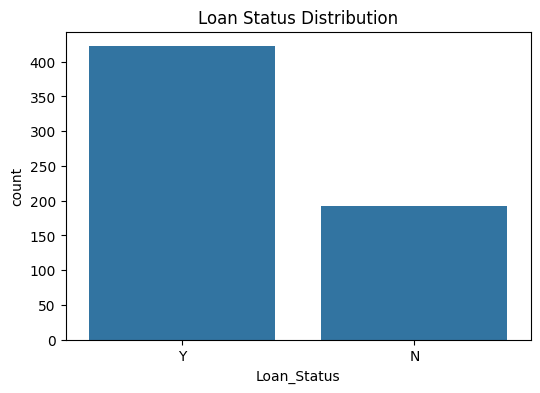

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Loan_Status")

plt.title("Loan Status Distribution")

plt.show()

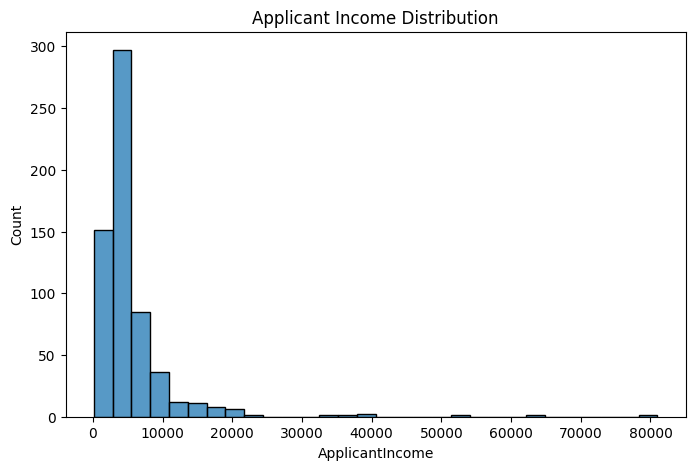

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["ApplicantIncome"], bins=30)

plt.title("Applicant Income Distribution")

plt.show()

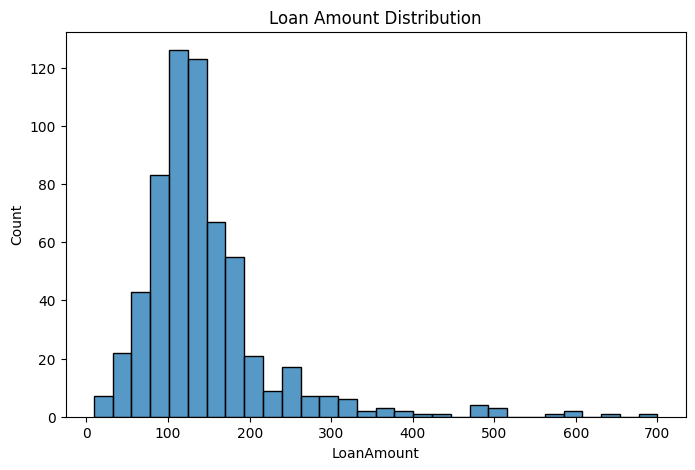

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["LoanAmount"], bins=30)

plt.title("Loan Amount Distribution")

plt.show()

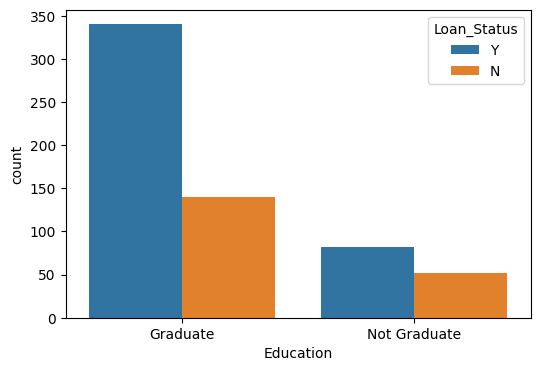

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Education",
              hue="Loan_Status")

plt.show()

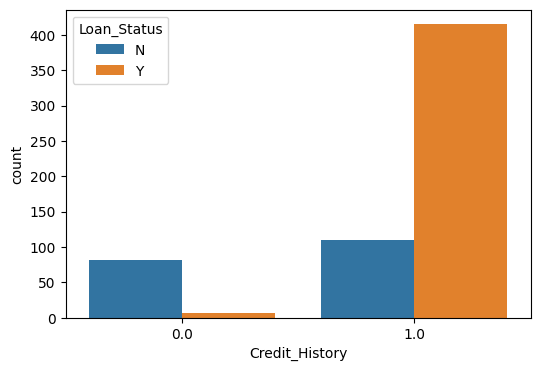

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Credit_History",
              hue="Loan_Status")

plt.show()

# Step 7: Encode Categorical Variables

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# Step 8: Prepare Features and Target

In [22]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

# Step 9: Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

# Step 10: Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Step 11: Logistic Regression Model

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [26]:
y_pred = model.predict(X_test)

# Step 12: Model Evaluation

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7886178861788617


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[18, 25],
       [ 1, 79]])

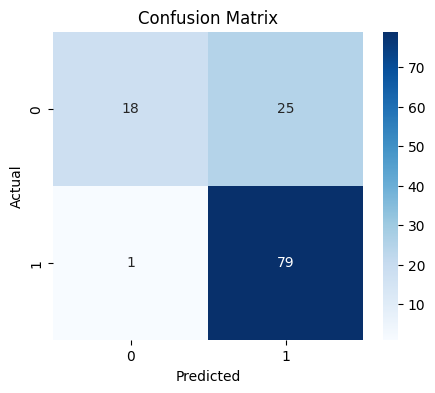

In [29]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



# Step 13: Decision Tree Model

In [31]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.6910569105691057


# Step 14: Feature Importance

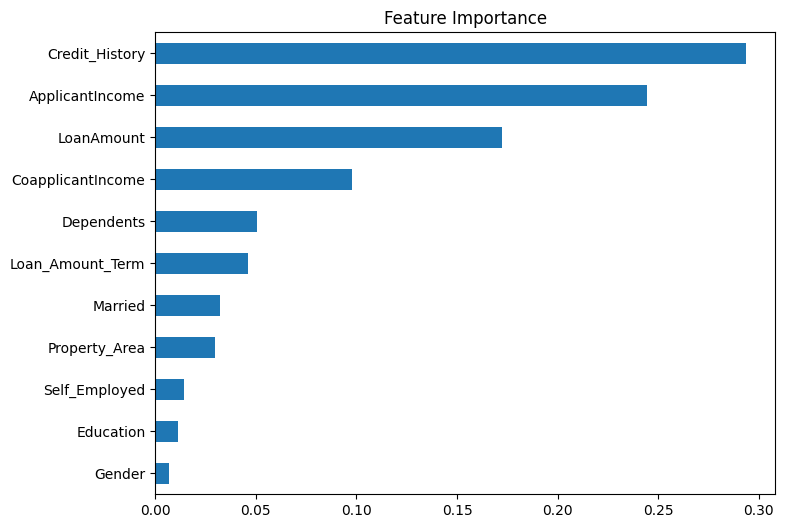

In [32]:
importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

# Conclusion

In this project, a Credit Risk Prediction model was developed using the Loan Prediction Dataset.

The dataset was cleaned by handling missing values, removing unnecessary columns, and encoding categorical features. Exploratory Data Analysis (EDA) helped understand the relationships between applicant characteristics and loan approval status.

Two classification models—Logistic Regression and Decision Tree—were trained and evaluated using accuracy, a confusion matrix, and a classification report. Feature importance analysis highlighted the variables that most influenced loan approval predictions.

This project demonstrates the complete workflow of a binary classification problem, from data preprocessing to model evaluation, and provides useful insights for supporting loan approval decisions.